# **Inteligencia Artificial y Aprendizaje Automático**
## **Maestría en Inteligencia Artificial Aplicada**
### **Dr Luis Eduardo Falcón Morales**
### **Tecnológico de Monterrey**
**Actividad Curvas ROC y PR**

#Carlos Fernando del Castillo Rey

#A01796595


# **INtroducción**

La actividad se basa en los datos conocidos como "oil-spill" (derrame de petróleo).

El archivo de los datos está en Canvas y se llama "oil-spill.csv".


En la siguiente liga se encuentra la liga del artículo relacionado a dicha base de datos. Los datos incluyen 50 columnas y 937 registros. Las primeras 49 columnas son métricas obtenidas de imágenes satelitales del océano, en algunas de las cuales se tiene petróleo que fue derramado por alguna fuente desconocida. En el artículo se describe a detalle la manera en que se obtuvieron dichas columnas. Para la actividad es suficiente considerarlas como de valor numérico. La última columna es de valor 1 (hay derrame en esa sección de la imagen) o 0 (no hay derrame en esa sección de la imagen).

https://webdocs.cs.ualberta.ca/~holte/Publications/oilspill.pdf

En la siguiente liga puedes encontrar información de varias de las métricas que estaremos utilizando:

https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

La media geométrica se puede obtener combinando las métricas anteriores, pero para fines prácticos usaremos la de la librería llamada "imbalanced-learn":

https://glemaitre.github.io/imbalanced-learn/generated/imblearn.metrics.geometric_mean_score.html

In [1]:
# Incluye todas las librerías que consideres adecuadas:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv

from collections import Counter  # Para analizar desbalanceo de clases

#  Selección de modelos y validación cruzada
from sklearn.model_selection import (
    train_test_split, 
    RepeatedStratifiedKFold, 
    cross_val_score, 
    cross_validate
)

# Modelo Dummy (para establecer una línea base de comparación)
from sklearn.dummy import DummyClassifier  

# Métricas de evaluación
from sklearn.metrics import (
    make_scorer, 
    roc_curve, 
    auc, 
    precision_recall_curve
)

#  Métrica especializada para datos desbalanceados
from imblearn.metrics import geometric_mean_score  

# Pipeline y Transformaciones de datos
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer  

# Modelos de Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier





Para fines de la actividad procesaremos los datos de manera estándar para concentrarnos en los temas de la actividad.

In [2]:
path = "D:\\Mestria\\ML\\oil_spill.csv"
df = read_csv(path, header=None)   # no tienen nombre las columnas

print('Timensión del DataFrame',df.shape)

# eliminamos las siguientes columnas:
df.drop(22, axis=1, inplace=True)    # Esta columna tiene un solo valor constante.
df.drop(0, axis=1, inplace=True)     # Esta columna contiene información de secciones (batches) de las imágenes, que no la requerimos.

df.columns = [i for i in range(df.shape[1])]   # Renombramos las columnas para que sean enteros consecutivos.

# Particionamos los datos de entrada (X) y de salida (y):
X,y = df.iloc[:,:-1], df.iloc[:,-1]

Xtv, Xtest, ytv, ytest = train_test_split(X, y, test_size=0.12, stratify=y, shuffle=True, random_state=0)
Xtrain, Xval, ytrain, yval = train_test_split(Xtv, ytv, test_size=0.2, shuffle=True, random_state=5)
print('\nPartición:')
print('Train: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytrain.sum(), 100*(ytrain.sum() / len(ytrain))))
print('Val: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (yval.sum(), 100*(yval.sum() / len(yval))))
print('Test: Conteo clase positiva=%d, Porcentaje=%.2f%%' % (ytest.sum(), 100*(ytest.sum() / len(ytest))))

Timensión del DataFrame (937, 50)

Partición:
Train: Conteo clase positiva=29, Porcentaje=4.40%
Val: Conteo clase positiva=7, Porcentaje=4.24%
Test: Conteo clase positiva=5, Porcentaje=4.42%


Breve descripción numérica y gráfica del conjunto de entrenamiento:

In [3]:
Xtrain.describe().T

,count,mean,std,min,25%,50%,75%,max
0,659.0,344.153263,1.880555e+03,10.00,22.000,65.00,134.500,28526.00
1,659.0,709.286161,5.993162e+02,1.95,97.475,727.45,1242.135,1893.08
2,659.0,867.791608,5.145066e+02,1.00,445.065,791.35,1243.220,2674.16
3,659.0,85.078907,4.573682e+01,0.00,55.000,74.00,119.000,180.00
4,659.0,824339.418816,4.131627e+06,70312.00,127500.000,187500.00,348750.000,71315000.00
5,659.0,42.966449,1.259403e+01,21.24,33.430,39.64,51.975,82.64
6,659.0,9.162307,3.587007e+00,0.83,6.920,8.22,10.755,24.28
7,659.0,4119.098634,8.899523e+03,667.00,1404.750,2167.00,3600.000,160740.00
8,659.0,0.222898,8.984421e-02,0.02,0.170,0.21,0.260,0.74
9,659.0,110.288771,6.272348e+01,47.00,82.950,99.80,115.700,901.70


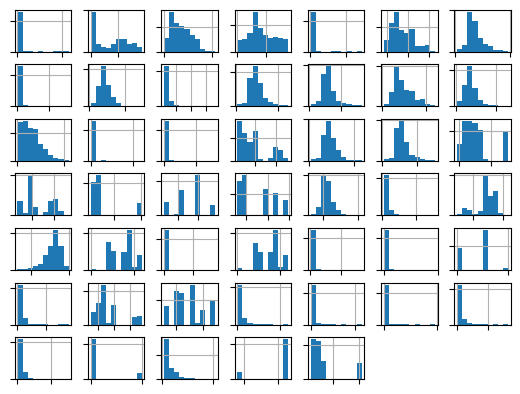

In [4]:
ax = Xtrain.hist()  # Histogramas:
# Quitemos toda la información del gráfico para visualizarlo de manera sencilla:
for axis in ax.flatten():
  axis.set_title('')
  axis.set_xticklabels([])
  axis.set_yticklabels([])
plt.show()

In [5]:
Xtrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 659 entries, 770 to 460
Data columns (total 47 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       659 non-null    int64  
 1   1       659 non-null    float64
 2   2       659 non-null    float64
 3   3       659 non-null    int64  
 4   4       659 non-null    float64
 5   5       659 non-null    float64
 6   6       659 non-null    float64
 7   7       659 non-null    float64
 8   8       659 non-null    float64
 9   9       659 non-null    float64
 10  10      659 non-null    float64
 11  11      659 non-null    float64
 12  12      659 non-null    float64
 13  13      659 non-null    float64
 14  14      659 non-null    float64
 15  15      659 non-null    float64
 16  16      659 non-null    float64
 17  17      659 non-null    float64
 18  18      659 non-null    float64
 19  19      659 non-null    float64
 20  20      659 non-null    float64
 21  21      659 non-null    float64
 22  22   

In [6]:
# Código-1:
# Aplicamos la función Dummy:

def evaluate_model(X, y, model):
  cv = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=1)
  metric = make_scorer(geometric_mean_score)
  scores = cross_val_score(model, X, y, scoring=metric, cv=cv, n_jobs=-1)
  return scores


modeloD = DummyClassifier(strategy='uniform')
scores = evaluate_model(X, y, modeloD)

print('Métrica G-mean - Media Geométrica: %.3f (%.3f)' % (np.mean(scores), np.std(scores)))

Métrica G-mean - Media Geométrica: 0.483 (0.095)


# **Ejercicio-1**

### **Explica lo que hace cada línea de código de la celda anterior llamada "Código-1", así como lo que significa el valor que se obtiene en su salida:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**


 
1.  Esta función recibe X (features), y (etiquetas) y un modelo como parámetros para evaluar su rendimiento.

2.  Se define la validación cruzada estratificada repetida:
        10 particiones (n_splits=10) Se Divide los datos en 10 partes y usa cada una como prueba en turnos.
        3 repeticiones (n_repeats=3) Se Repite el proceso 3 veces para mayor estabilidad.
        random_state=1 Se Asegura resultados reproducibles.

3.   Define la métrica de evaluación:
        geometric_mean_score es la media geométrica de sensibilidad/recall en cada clase.
        Se usa make_scorer() para que la métrica sea compatible con cross_val_score().

4.   Entrena y evalúa el modelo con validación cruzada:

        cross_val_score() ejecuta el modelo en cada división del dataset.
        scoring=metric Se Usa la métrica de G-mean en cada validación.
        cv=cv → Utiliza la validación cruzada estratificada definida antes.
        n_jobs=-1 Se Usa todos los núcleos del procesador para acelerar el cálculo.

5.   Retorna una lista con las puntuaciones G-mean obtenidas en cada validación.


6.   Se crea un DummyClassifier con strategy='uniform':
        "Uniform" Se predice aleatoriamente las clases con la misma probabilidad.
        No usa datos reales para aprender, solo lanza predicciones al azar.

7.    Se evalúa el modelo Dummy llamando a evaluate_model(), obteniendo la lista de G-mean en cada validación.

8.   np.mean(scores) Se promedia de G-mean en todas las validaciones.
        np.std(scores) Es Variabilidad de G-mean en las validaciones.
        Se imprime con formato de tres decimales.

9.   Significado del valor de salida:
    Esto significa que el Dummy logra un rendimiento pobre, cercano al azar (0.5), lo que sugiere que el dataset puede estar desbalanceado o que la clasificación es difícil.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

Para fines de esta actividad definimos las siguientes transformaciones del preprocesamiento de los datos:

In [7]:
# Transforamaciones numéricas:

numericas_pipeline = Pipeline(steps = [('impMediana', SimpleImputer(strategy='mean')),
                                       ('std_transformer', StandardScaler())])
numericas_pipeline_nombres = Xtrain.columns

columnasTransformer = ColumnTransformer(transformers = [('num', numericas_pipeline, numericas_pipeline_nombres)],
                                        remainder='passthrough')

In [8]:
mi_metrica = make_scorer(geometric_mean_score)  # definimos la métrica G-mean

Resultados de Validación:
LR
Exactitud: >> 0.951 (0.015)
G-mean: >> 0.733 (0.093)

LASSO
Exactitud: >> 0.968 (0.009)
G-mean: >> 0.689 (0.104)

RIDGE
Exactitud: >> 0.969 (0.011)
G-mean: >> 0.725 (0.108)

EN
Exactitud: >> 0.968 (0.010)
G-mean: >> 0.694 (0.112)

kNN
Exactitud: >> 0.966 (0.005)
G-mean: >> 0.464 (0.204)



C:\Users\52614\AppData\Local\Temp\ipykernel_29452\124202979.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados1, labels=nombres,  showmeans=True)


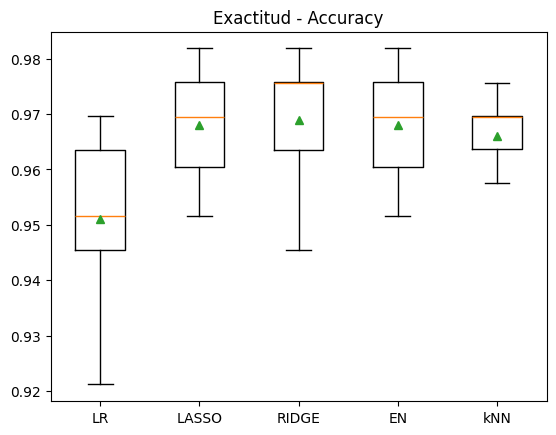

C:\Users\52614\AppData\Local\Temp\ipykernel_29452\124202979.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados2, labels=nombres,  showmeans=True)


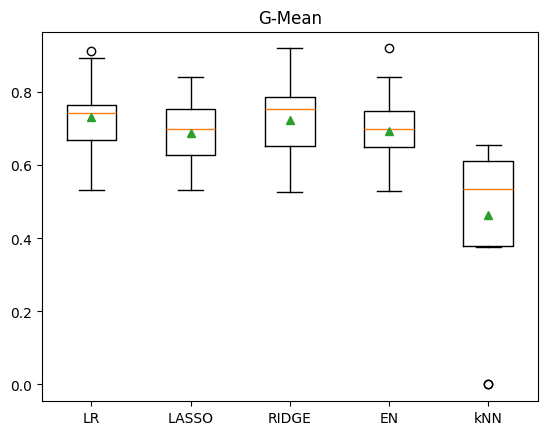

In [9]:
# Código-2:
# ACCURACY & G-mean

def mis_modelos1():
  modelos, nombres = list(), list()

  modelos.append(LogisticRegression(penalty=None,
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LR')


  modelos.append(LogisticRegression(penalty='l1',
                                    solver='liblinear',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('LASSO')


  modelos.append(LogisticRegression(penalty='l2',
                                    max_iter=2000,
                                    random_state=1))
  nombres.append('RIDGE')

  modelos.append(LogisticRegression(penalty='elasticnet',
                                    l1_ratio=0.5,
                                    solver='saga',
                                    max_iter=5000,
                                    random_state=1))
  nombres.append('EN')

  modelos.append(KNeighborsClassifier(n_neighbors=5))
  nombres.append('kNN')

  return modelos, nombres

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


modelos, nombres = mis_modelos1()
resultados1, resultados2 = list(), list()

print('Resultados de Validación:')
for i in range(len(modelos)):

  pipeline = Pipeline(steps=[('ct',columnasTransformer),('m',modelos[i])])
  cv1 = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
  scores = cross_validate(pipeline,
                          Xtv,
                          np.ravel(ytv),
                          scoring={'exactitud':'accuracy', 'm_geo':mi_metrica},
                          cv=cv1)

  resultados1.append(scores['test_exactitud'])
  resultados2.append(scores['test_m_geo'])

  print(nombres[i])
  print('Exactitud: >> %.3f (%.3f)' % (np.nanmean(scores['test_exactitud']), np.nanstd(scores['test_exactitud'])))
  print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
  print()

plt.boxplot(resultados1, labels=nombres,  showmeans=True)
plt.title("Exactitud - Accuracy")
plt.show()

plt.boxplot(resultados2, labels=nombres,  showmeans=True)
plt.title("G-Mean")
plt.show()


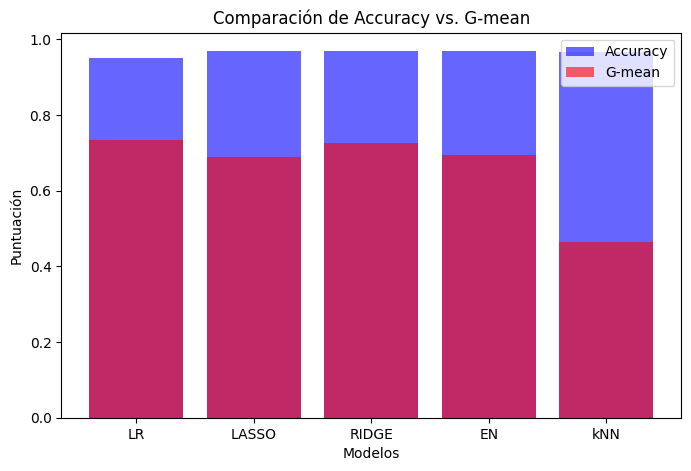

In [10]:
#Se crea el grafico de barras para poder visualizar la comparacion entre G-mean y el primedio de la exactitud
# Modelos utilizados
modelos = ['LR', 'LASSO', 'RIDGE', 'EN', 'kNN']

# Obtener los valores de los resultados
accuracy_scores = [np.nanmean(scores) for scores in resultados1]  # Exactitud promedio
gmean_scores = [np.nanmean(scores) for scores in resultados2]  # G-mean promedio

# Crear el gráfico de barras
plt.figure(figsize=(8, 5))

# Graficar Accuracy
plt.bar(modelos, accuracy_scores, color='blue', alpha=0.6, label='Accuracy')

# Graficar G-mean
plt.bar(modelos, gmean_scores, color='red', alpha=0.6, label='G-mean')

# Etiquetas y título
plt.xlabel('Modelos')
plt.ylabel('Puntuación')
plt.title('Comparación de Accuracy vs. G-mean')
plt.legend()

# Mostrar gráfico
plt.show()

# **Ejercicio-2**

### **Explica por qué la salida y gráficos anteriores nos ayudan a respaldar la decisión de usar la métrica G-mean, en lugar de la exactitud (accuracy) en este problema:**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**

Los resultados de validación muestran que la exactitud (accuracy) es muy alta (≥ 95%) en todos los modelos, pero la métrica G-mean varía mucho entre ellos. Esto sugiere que la exactitud no es una buena métrica en este caso
Si los datos están desbalanceados (es decir, hay muchas más muestras de una clase que de la otra), un modelo puede lograr una alta exactitud simplemente prediciendo siempre la clase mayoritaria sin aprender realmente el patrón de la clase minoritaria.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-3**

### **Utilizando en adelante solamente la métrica G-mean y de manera análoga al código de la celda llamada "Código-2" anterior, define una función llamada "mis_modelos2()" y utilízala para definir los mismos modelos de regresión logística, pero incluyendo el argumento class_weight='balanced'. Los demás hiperparámetros los puedes variar si así lo consideras adecuado. Incluye kNN, aunque no tiene argumento para balanceo de las clases de salida.**

Resultados de Validación (G-Mean):
LR
G-mean: >> 0.693 (0.117)

LASSO
G-mean: >> 0.849 (0.069)

RIDGE
G-mean: >> 0.852 (0.070)

EN
G-mean: >> 0.851 (0.070)

kNN
G-mean: >> 0.464 (0.204)



C:\Users\52614\AppData\Local\Temp\ipykernel_29452\2100117134.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados2, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.


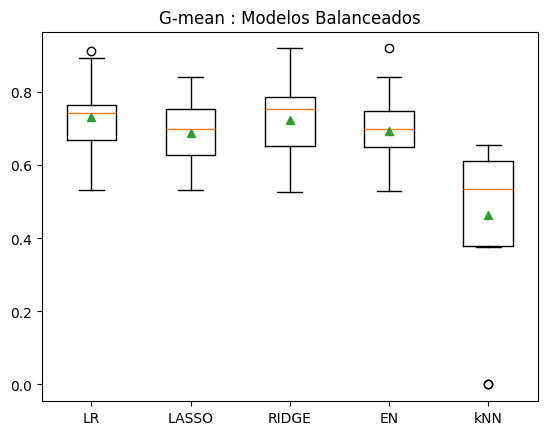

In [11]:
#  Casos balancedos con hiperparámetro de Regresión Logística:

# ++++++++++ Inicia sección para agregar tu código ++++++++++++++++++++++++
def mis_modelos2():
    modelos, nombres2 = list(), list()

    modelos.append(LogisticRegression(penalty=None,  # Cambiado 'none' -> None
                                      max_iter=3000,
                                      class_weight='balanced',
                                      random_state=1))
    nombres2.append('LR')

    modelos.append(LogisticRegression(penalty='l1',
                                      solver='liblinear',
                                      max_iter=3000,
                                      class_weight='balanced',
                                      random_state=1))
    nombres2.append('LASSO')

    modelos.append(LogisticRegression(penalty='l2',
                                      solver='lbfgs',
                                      max_iter=3000,
                                      class_weight='balanced',
                                      random_state=1))
    nombres2.append('RIDGE')

    modelos.append(LogisticRegression(penalty='elasticnet',
                                      l1_ratio=0.5,
                                      solver='saga',
                                      max_iter=5000,
                                      class_weight='balanced',
                                      random_state=1))
    nombres2.append('EN')

    modelos.append(KNeighborsClassifier(n_neighbors=5))
    nombres2.append('kNN')

    return modelos, nombres2

# Definir modelos
modelos, nombres2 = mis_modelos2()
resultados = list()

print('Resultados de Validación (G-Mean):')

for i in range(len(modelos)):
    pipeline = Pipeline(steps=[('ct', columnasTransformer), ('m', modelos[i])])
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=7)
    
    scores = cross_validate(pipeline,
                            Xtv,
                            np.ravel(ytv),
                            scoring={'m_geo': mi_metrica},
                            cv=cv)
    
    resultados.append(scores['test_m_geo'])

    print(nombres2[i])
    print('G-mean: >> %.3f (%.3f)' % (np.nanmean(scores['test_m_geo']), np.nanstd(scores['test_m_geo'])))
    print()

# ++++++++++ Termina sección para agregar tu código ++++++++++++++++++++++++


plt.boxplot(resultados2, labels=nombres2,  showmeans=True)   # gráficos de caja para una comparación visual de los resultados.
plt.title("G-mean : Modelos Balanceados")
plt.show()

# **Ejercicio-4**

### **4a) Selecciona el que consideres sea el mejor modelo encontrado hasta ahora y utilízalo para obtener los gráficos curva-ROC y curva-PR, así como los valores de sus áreas bajo la curva. Sigue utilizando los conjuntos de entrenamiento y validación.**



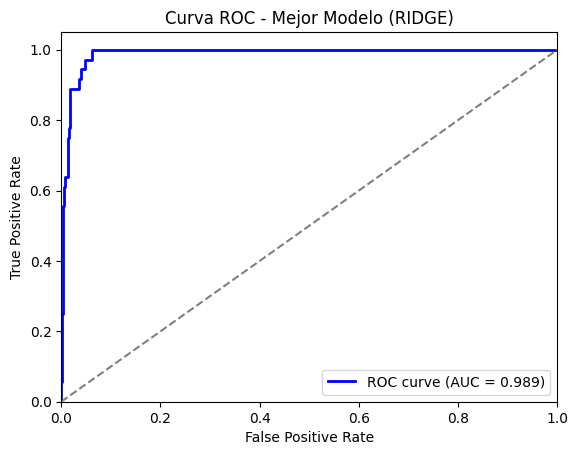

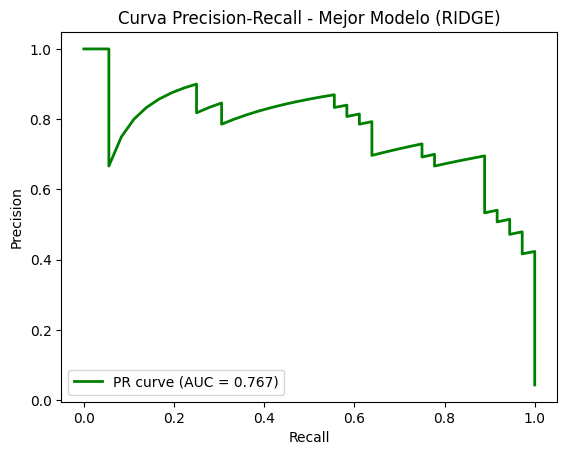

AUC-ROC: 0.989
AUC-PR: 0.767


In [12]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.


# Normalizar los datos para mejorar estabilidad del modelo
scaler = StandardScaler()
Xtv_scaled = scaler.fit_transform(Xtv)

# Definir el mejor modelo (RIDGE con class_weight='balanced')
mejor_modelo = LogisticRegression(penalty='l2',  # Regularización Ridge
                                  solver='lbfgs',  # Algoritmo estable para convergencia
                                  max_iter=3000,   # Aumentar iteraciones para mejor ajuste
                                  class_weight='balanced',  # Ajuste de pesos para clases desbalanceadas
                                  random_state=1)

# Entrenar el modelo con los datos normalizados
mejor_modelo.fit(Xtv_scaled, np.ravel(ytv))

# Obtener las predicciones de probabilidad en el conjunto de validación
y_scores = mejor_modelo.predict_proba(Xtv_scaled)[:, 1]  # Probabilidad de la clase positiva

# Calcular la curva ROC y el AUC-ROC
fpr, tpr, _ = roc_curve(ytv, y_scores)
roc_auc = auc(fpr, tpr)

# Calcular la curva Precision-Recall y el AUC-PR
precision, recall, _ = precision_recall_curve(ytv, y_scores)
pr_auc = auc(recall, precision)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Mejor Modelo (RIDGE)')
plt.legend(loc='lower right')
plt.show()

# Graficar la curva Precision-Recall
plt.figure()
plt.plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Mejor Modelo (RIDGE)')
plt.legend(loc='lower left')
plt.show()

# Imprimir los valores de AUC-ROC y AUC-PR
print(f"AUC-ROC: {roc_auc:.3f}")
print(f"AUC-PR: {pr_auc:.3f}")


# **+++++++++++ Termina sección para agregar código ++++++++++++++**

### **4b) Incluye tus conclusiones de los gráficos obtenidos en el inciso anterior.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**

Un AUC-ROC de 0.989 es excelente. Significa que el modelo distingue muy bien entre clases, pero curva está muy pegada al eje superior izquierdo lo que indica que el modelo tiene una alta tasa de verdaderos positivos y una baja tasa de falsos positivos.
El modelo es muy bueno para clasificar correctamente ambas clases, pero como  está desbalanceado, la curva Precision-Recall es más importante.

El modelo RIDGE es excelente en términos generales (AUC-ROC = 0.989) ,Pero  la métrica AUC-PR = 0.767 indica que la detección de la clase minoritaria podría mejorar.
AUC-PR de 0.767 es bueno, pero no perfecto.
La curva tiene altibajos, lo que indica variabilidad en la precisión cuando el recall aumenta.
A medida que aumenta el recall, la precisión baja, lo que indica que el modelo empieza a cometer más errores al tratar de detectar más positivos.
El modelo no es tan bueno detectando la clase minoritaria como sugiere la ROC.



**+++++++++++ Termina sección para agregar texto ++++++++++++++**

# **Ejercicio-5**

### **Utiliza el conjunto de prueba (test) para evaluar el mejor modelo obtenido.**

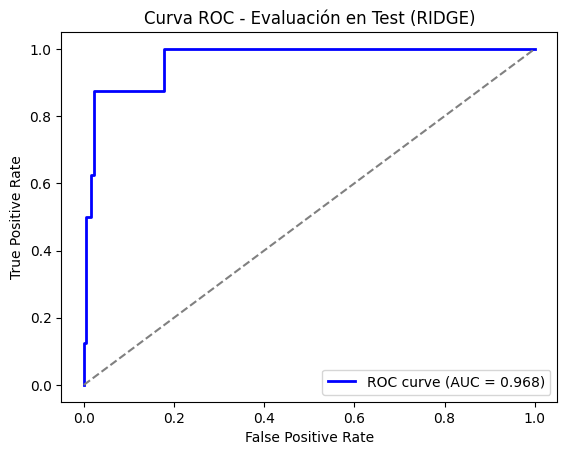

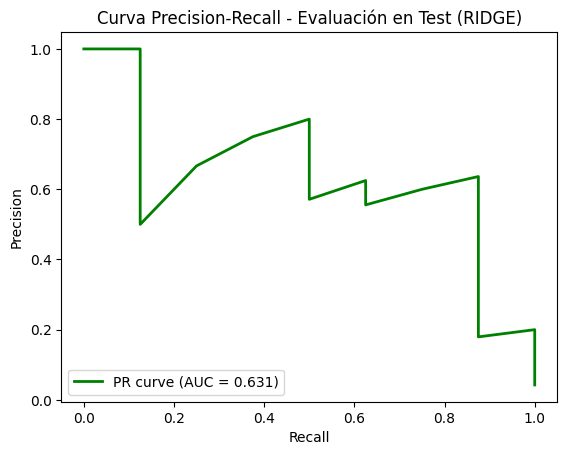

AUC-ROC en Test: 0.968
AUC-PR en Test: 0.631


In [13]:
# **+++++++++++ Inicia sección para agregar código ++++++++++++++++**
# NOTA: puedes agregar todas las celdas que consideres adecuado.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Normalizar el conjunto de prueba con el mismo scaler usado en entrenamiento
X_test_scaled = scaler.transform(X_test)  

# Obtener predicciones en test
y_test_scores = mejor_modelo.predict_proba(X_test_scaled)[:, 1]

# Calcular métricas en test
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_scores)
roc_auc_test = auc(fpr_test, tpr_test)
precision_test, recall_test, _ = precision_recall_curve(y_test, y_test_scores)
pr_auc_test = auc(recall_test, precision_test)

# Graficar Curva ROC en Test
plt.figure()
plt.plot(fpr_test, tpr_test, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Línea de referencia
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Evaluación en Test (RIDGE)')
plt.legend(loc='lower right')
plt.show()

# Graficar Curva Precision-Recall en Test
plt.figure()
plt.plot(recall_test, precision_test, color='green', lw=2, label=f'PR curve (AUC = {pr_auc_test:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall - Evaluación en Test (RIDGE)')
plt.legend(loc='lower left')
plt.show()

# Imprimir valores de AUC-ROC y AUC-PR en Test
print(f"AUC-ROC en Test: {roc_auc_test:.3f}")
print(f"AUC-PR en Test: {pr_auc_test:.3f}")





# **+++++++++++ Termina sección para agregar código ++++++++++++++**

# **Ejercicio-6**

### **Incluye tus conclusiones finales de los resultados obtenidos y de la actividad en general.**

**+++++++++++ Inicia sección para agregar texto ++++++++++++++++**


El modelo RIDGE ha demostrado un excelente desempeño global, con una capacidad significativa para distinguir entre clases. Sin embargo, su capacidad para detectar correctamente la clase minoritaria debe de mejorar.

1️) AUC-ROC alto (0.989) indica que el modelo separa bien las clases y tiene una baja tasa de falsos positivos.
2️) AUC-PR moderado (0.767) sugiere que la precisión en la clase minoritaria aún puede optimizarse, lo que es crucial en datasets desbalanceados.

Aunque los métodos estadísticos utilizados han sido útiles para entrenar el modelo, es importante reconocer que el proceso de análisis de datos también puede introducir sesgos. Esto ocurre porque: Los datos pueden estar desbalanceados o tener ruido, lo que afecta el rendimiento del modelo, ,as decisiones sobre la selección, limpieza y normalización de datos están influenciadas por la persona que realiza el análisis, lo que puede introducir subjetividad o/y los parámetros del modelo deben ajustarse de manera cuidadosa, ya que decisiones mal calibradas pueden reforzar patrones no deseados en los datos.

Este caso no es único, ya que los modelos de Machine Learning son herramientas para solucionar problemas del mundo real, donde:
Los datos pueden variar constantemente y no siempre se presentan en condiciones ideales ademas de ser necesario ajustar los modelos y evaluar múltiples métricas para garantizar un buen rendimiento en diferentes escenarios y la metodología debe adaptarse a distintos contextos y bases de datos, asegurando que el modelo sea robusto y generalizable.




**+++++++++++ Termina sección para agregar texto ++++++++++++++**

## **<<< Fin de la Actividad de la Semana - curvas ROC y PR >>>**